In [6]:
from skimage.transform import radon, iradon
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob
from PIL import Image
from torch.utils.data import DataLoader


import sys
sys.path.append("..")  # aggiunge la cartella padre (project/) al path
from data.dataset import MayoDatasetNpy
from data.preprocessing import get_transform


In [29]:
PREPROCESSED_PATH = "../data/preprocessed"

train_images_npy = glob(os.path.join(PREPROCESSED_PATH, "train", "*.npy"))
val_images_npy   = glob(os.path.join(PREPROCESSED_PATH, "validation", "*.npy"))
test_images_npy  = glob(os.path.join(PREPROCESSED_PATH, "test", "*.npy"))

train_loader = DataLoader(MayoDatasetNpy(train_images_npy), batch_size=8, shuffle=True)
val_loader   = DataLoader(MayoDatasetNpy(val_images_npy),   batch_size=8, shuffle=False)
test_loader  = DataLoader(MayoDatasetNpy(test_images_npy),  batch_size=8, shuffle=False)

noise_level = 0.005
ANGLE_CONFIGS = [180, 90, 60, 45]

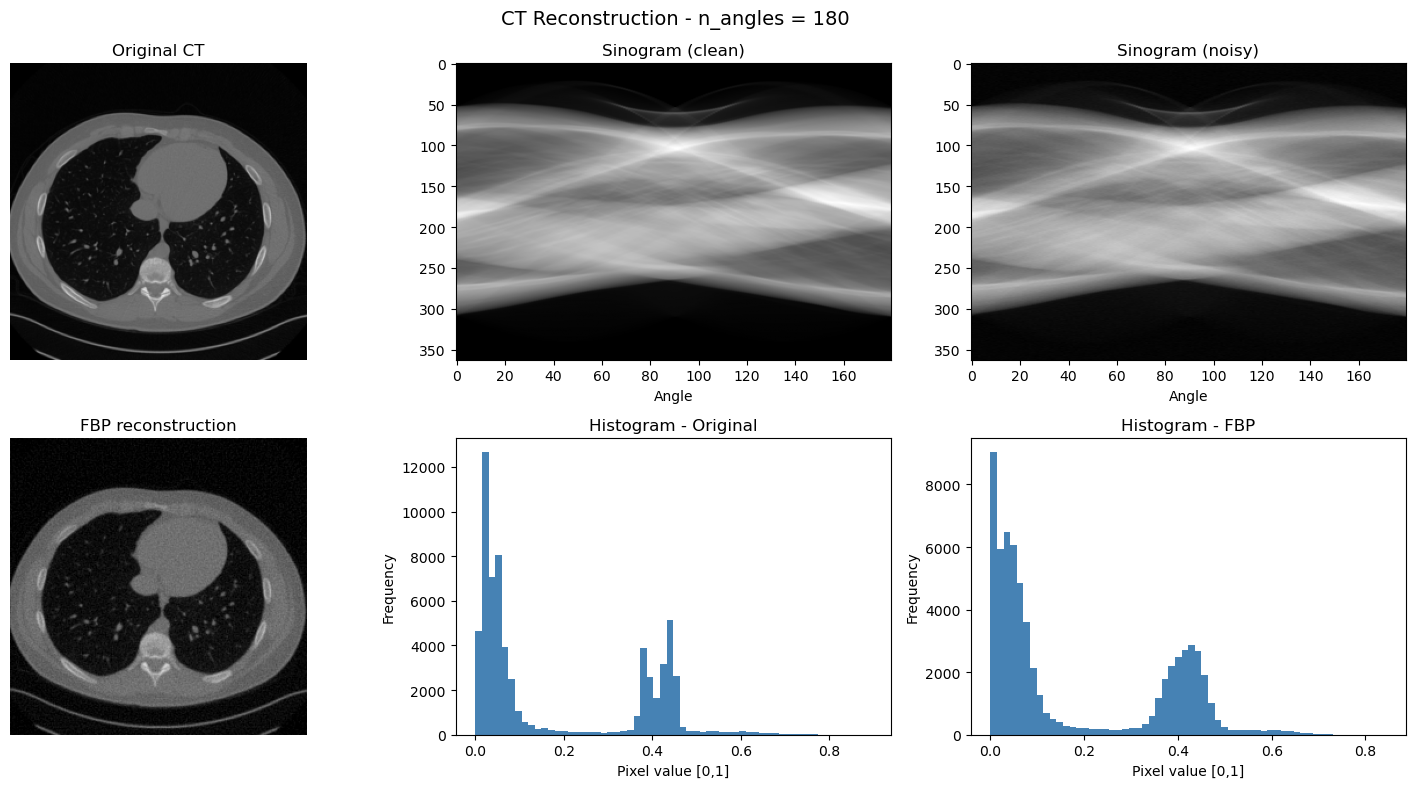

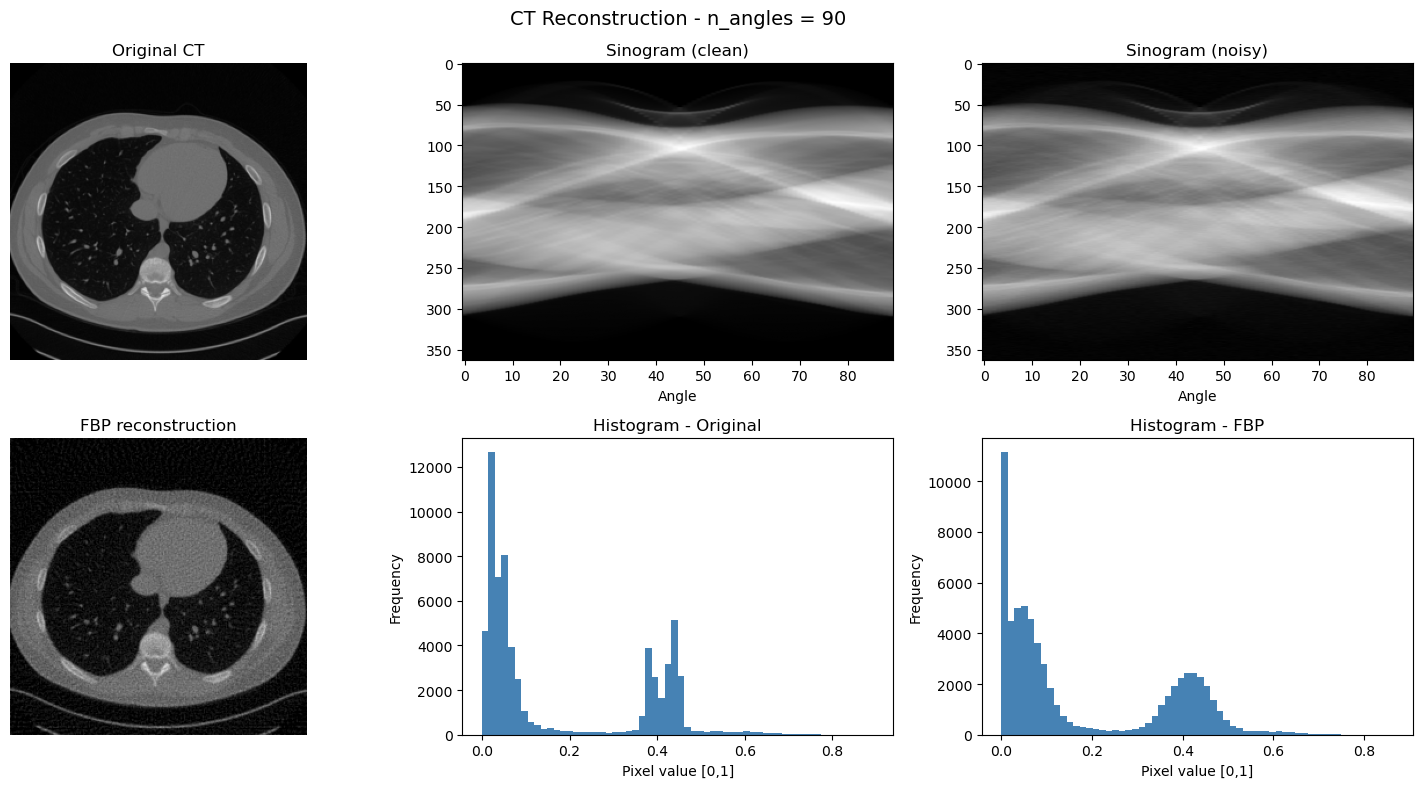

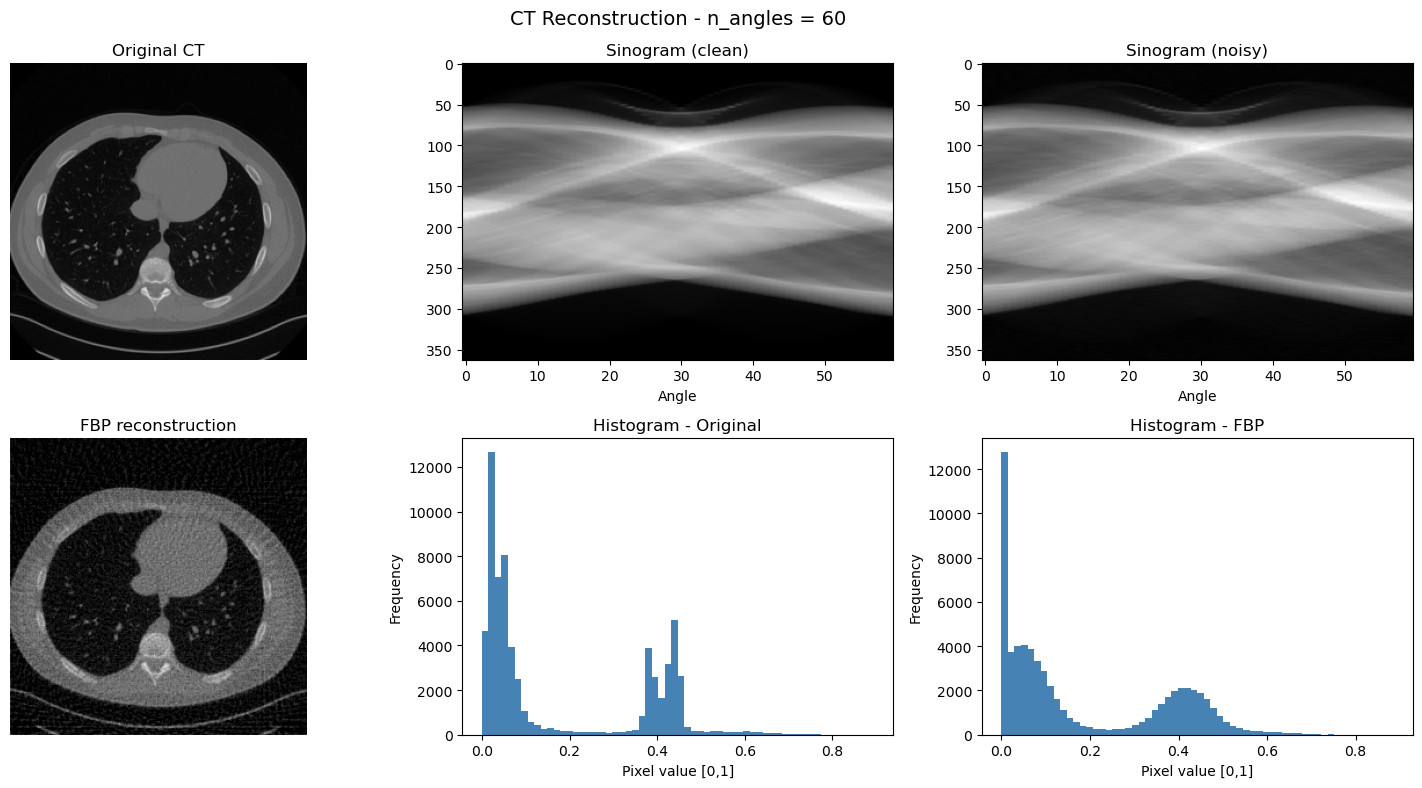

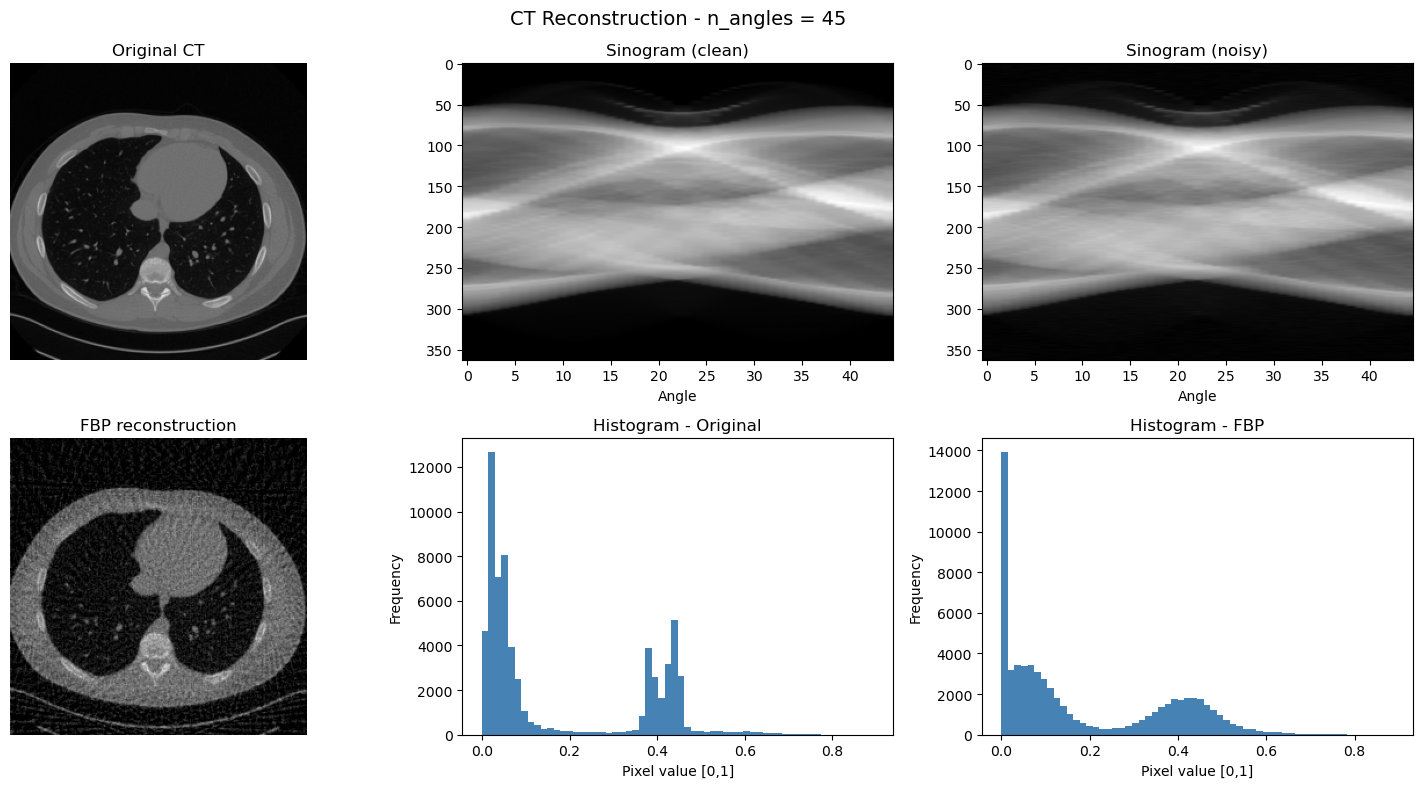

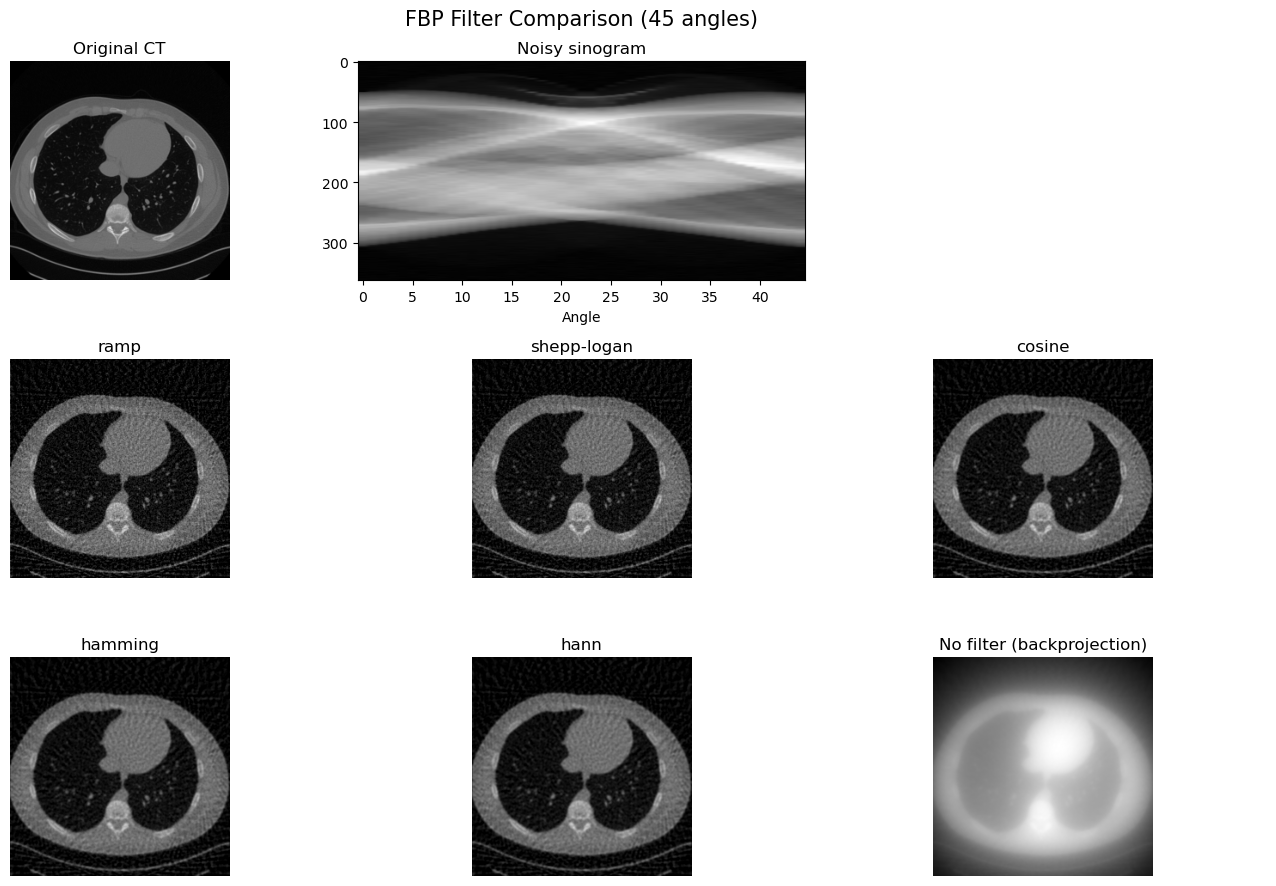

In [ ]:

# carica un'immagine dal nuovo sistema
img_2d = np.load(train_images_npy[2])   # shape (256, 256), float32 [0,1]



for n_angles in ANGLE_CONFIGS:

    angles = np.linspace(0, 180, n_angles, endpoint=False)

    # =========================================================
    # FORWARD PROJECTION
    # =========================================================
    sinogram = radon(img_2d, theta=angles, circle=False)

    # =========================================================
    # ADD GAUSSIAN NOISE
    # =========================================================
    noisy_sinogram = sinogram + np.random.normal(
        0,
        noise_level * sinogram.max(),
        sinogram.shape
    )

    # =========================================================
    # FBP RECONSTRUCTION
    # =========================================================
    fbp = iradon(
        noisy_sinogram,
        theta=angles,
        filter_name='ramp',
        circle=False
    )
    fbp = np.clip(fbp, 0, 1)

    # =========================================================
    # PLOT
    # =========================================================
    orig_pixels = img_2d.flatten()
    fbp_pixels  = fbp.flatten()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"CT Reconstruction - n_angles = {n_angles}", fontsize=14)

    axes[0, 0].imshow(img_2d, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title("Original CT")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(sinogram, cmap='gray', aspect='auto')
    axes[0, 1].set_title("Sinogram (clean)")
    axes[0, 1].set_xlabel("Angle")

    axes[0, 2].imshow(noisy_sinogram, cmap='gray', aspect='auto')
    axes[0, 2].set_title("Sinogram (noisy)")
    axes[0, 2].set_xlabel("Angle")

    axes[1, 0].imshow(fbp, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title("FBP reconstruction")
    axes[1, 0].axis("off")

    axes[1, 1].hist(orig_pixels, bins=60, color='steelblue', edgecolor='none')
    axes[1, 1].set_title("Histogram - Original")
    axes[1, 1].set_xlabel("Pixel value [0,1]")
    axes[1, 1].set_ylabel("Frequency")

    axes[1, 2].hist(fbp_pixels, bins=60, color='steelblue', edgecolor='none')
    axes[1, 2].set_title("Histogram - FBP")
    axes[1, 2].set_xlabel("Pixel value [0,1]")
    axes[1, 2].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# FILTER COMPARISON
# ============================================================
noise_level = 0.005
n_angles    = 45
filters     = ['ramp', 'shepp-logan', 'cosine', 'hamming', 'hann', None]

angles = np.linspace(0, 180, n_angles, endpoint=False)

sinogram       = radon(img_2d, theta=angles, circle=False)
noisy_sinogram = sinogram + np.random.normal(0, noise_level * sinogram.max(), sinogram.shape)

fig, axes = plt.subplots(3, 3, figsize=(14, 9))
fig.suptitle(f"FBP Filter Comparison ({n_angles} angles)", fontsize=15)

axes[0, 0].imshow(img_2d, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title("Original CT")
axes[0, 0].axis("off")

axes[0, 1].imshow(noisy_sinogram, cmap='gray', aspect='auto')
axes[0, 1].set_title("Noisy sinogram")
axes[0, 1].set_xlabel("Angle")

axes[0, 2].axis("off")

for idx, filt in enumerate(filters[:3]):
    row, col = 1, idx
    recon = iradon(noisy_sinogram, theta=angles, filter_name=filt, circle=False)
    recon = np.clip(recon, 0, 1)
    axes[row, col].imshow(recon, cmap='gray', vmin=0, vmax=1)
    axes[row, col].set_title(filt)
    axes[row, col].axis("off")
for idx, filt in enumerate(filters[3:7]):
    row, col = 2, idx
    recon = iradon(noisy_sinogram, theta=angles, filter_name=filt, circle=False)
    
    # normalizza invece di clippare solo per None
    if filt is None:
        recon = (recon - recon.min()) / (recon.max() - recon.min())
        title = "No filter (backprojection)"
    else:
        recon = np.clip(recon, 0, 1)
        title = filt
    
    axes[row, col].imshow(recon, cmap='gray', vmin=0, vmax=1)
    axes[row, col].set_title(title)
    axes[row, col].axis("off")
plt.tight_layout()
plt.show()

Dimensioni di img_2d: torch.Size([1, 1, 256, 256])
Numero totale di elementi: 65536
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


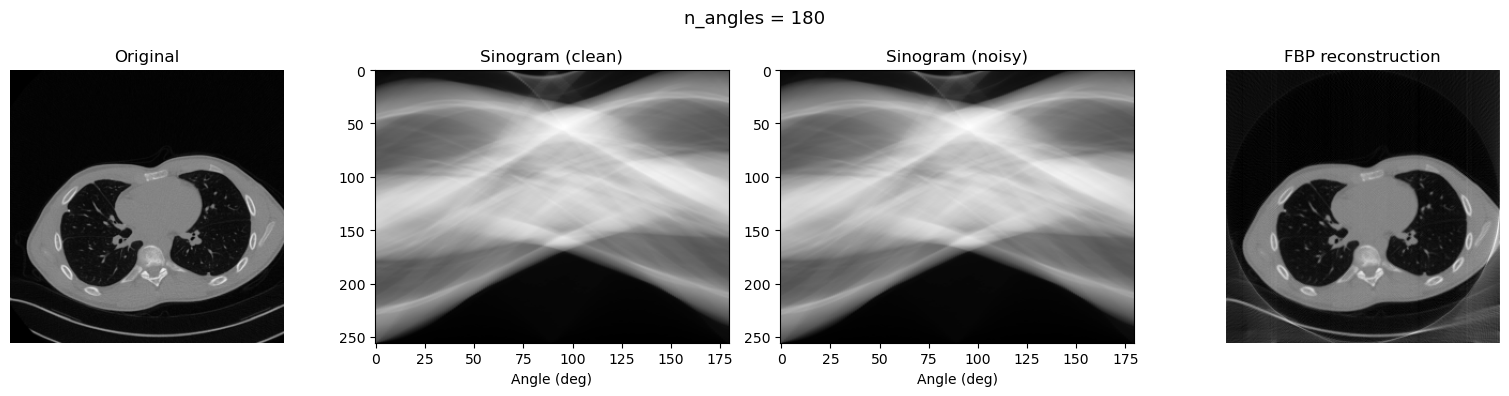

Dimensioni di img_2d: torch.Size([1, 1, 256, 256])
Numero totale di elementi: 65536
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


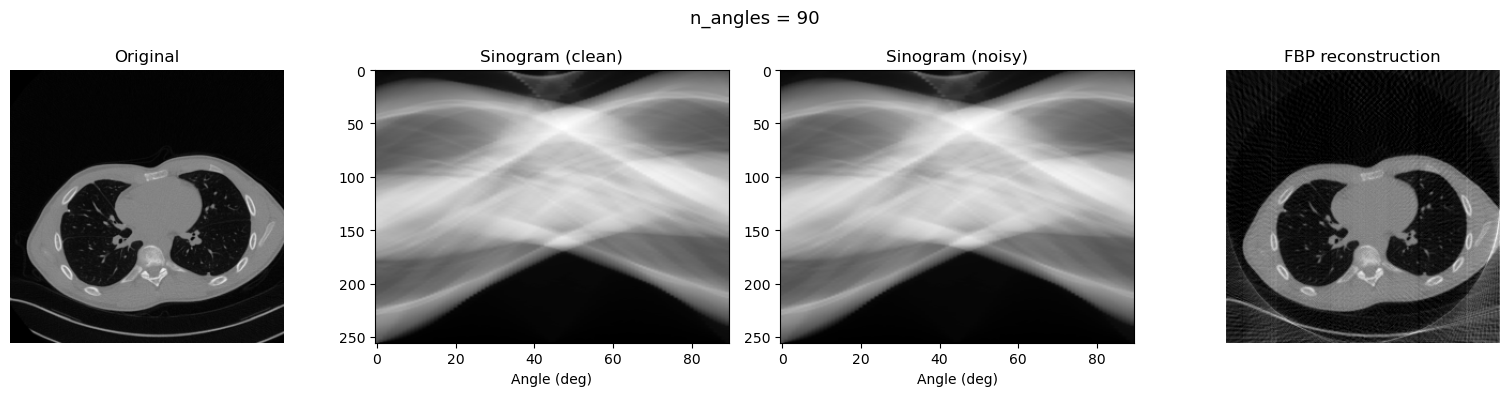

Dimensioni di img_2d: torch.Size([1, 1, 256, 256])
Numero totale di elementi: 65536
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


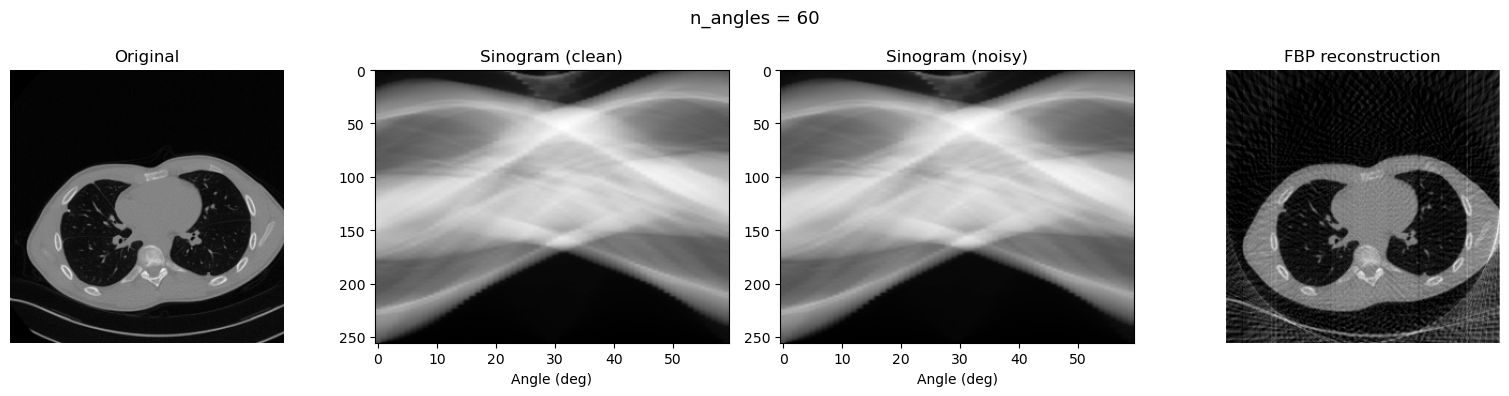

Dimensioni di img_2d: torch.Size([1, 1, 256, 256])
Numero totale di elementi: 65536
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


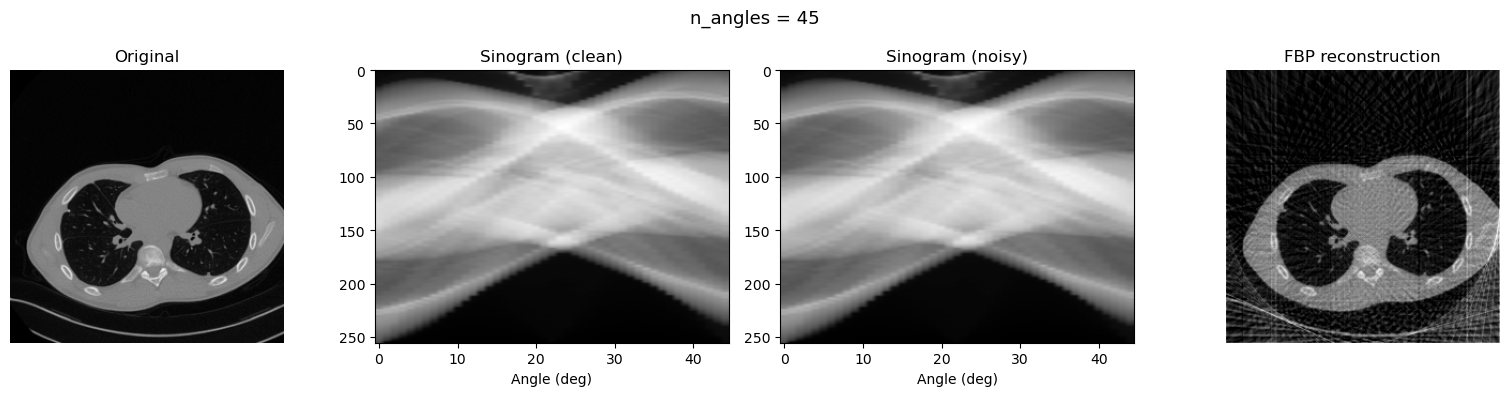

In [28]:
from ippy import operators, solvers
from ippy.metrics import SSIM, PSNR, RE
import torch

noise_level = 0
ANGLE_CONFIGS = [180, 90, 60, 45]

# carica l'immagine dal nuovo sistema
img_2d = torch.from_numpy(np.load(train_images_npy[0])).unsqueeze(0).unsqueeze(0)  # [1, 1, 256, 256]

for n_angles in ANGLE_CONFIGS:

    angles = np.linspace(0, np.pi, n_angles, endpoint=True)

    print(f"Dimensioni di img_2d: {img_2d.shape}")
    print(f"Numero totale di elementi: {img_2d.numel()}")

    K = operators.CTProjector(
        img_shape=(256, 256),
        angles=angles,
        det_size=256,
        geometry="parallel"
    )

    sinogram       = K(img_2d)
    ampiezza_rumore = noise_level * sinogram.max()
    sinogram_noisy  = sinogram + ampiezza_rumore * torch.randn_like(sinogram)

    solver1 = solvers.FBP(K)
    x_sol, info = solver1(
        sinogram_noisy,
        x_true=img_2d,
        starting_point=sinogram_noisy
    )

    # per il plot usa squeeze() senza sovrascrivere img_2d
    img_plot      = img_2d.squeeze()
    sino_plot     = sinogram.squeeze()
    sino_noisy_plot = sinogram_noisy.squeeze()
    recon_plot    = x_sol.squeeze()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"n_angles = {n_angles}", fontsize=13)

    axes[0].imshow(img_plot, cmap=plt.cm.Greys_r, vmin=0, vmax=1)
    axes[0].set_title("Original")
    axes[0].axis("off")



    axes[1].imshow(sino_plot.T, cmap=plt.cm.Greys_r, aspect='auto')
    axes[1].set_title("Sinogram (clean)")
    axes[1].set_xlabel("Angle (deg)")

    axes[2].imshow(sino_noisy_plot.T, cmap=plt.cm.Greys_r, aspect='auto')
    axes[2].set_title("Sinogram (noisy)")
    axes[2].set_xlabel("Angle (deg)")

    axes[3].imshow(recon_plot, cmap=plt.cm.Greys_r, vmin=0, vmax=1)
    axes[3].set_title("FBP reconstruction")
    axes[3].axis("off")

    fig.tight_layout()
    plt.show()

In [ ]:

# ============================================================
# SAVE SINOGRAMS
# ============================================================

def save_sinograms(dataset, split_name):

    for idx in range(len(dataset)):

        img = dataset[idx].squeeze().numpy()

        for n_angles in ANGLE_CONFIGS:

            angles = np.linspace(
                0,
                180,
                n_angles,
                endpoint=False
            )

            # ------------------------------------------------
            # CLEAN SINOGRAM
            # ------------------------------------------------
            sinogram = radon(
                img,
                theta=angles,
                circle=False
            )

            # ------------------------------------------------
            # NOISY SINOGRAM
            # ------------------------------------------------
            noisy_sinogram = sinogram + np.random.normal(
                0,
                noise_level * sinogram.max(),
                sinogram.shape
            )

            # ------------------------------------------------
            # NORMALIZATION FOR SAVING
            # ------------------------------------------------
            sinogram_norm = (
                sinogram - sinogram.min()
            ) / (
                sinogram.max() - sinogram.min() + 1e-8
            )

            noisy_norm = (
                noisy_sinogram - noisy_sinogram.min()
            ) / (
                noisy_sinogram.max() - noisy_sinogram.min() + 1e-8
            )

            sinogram_uint8 = (
                sinogram_norm * 255
            ).astype(np.uint8)

            noisy_uint8 = (
                noisy_norm * 255
            ).astype(np.uint8)

            # ------------------------------------------------
            # SAVE PATHS
            # ------------------------------------------------
            clean_path = os.path.join(
                SINOGRAM_CLEAN_PATH,
                split_name,
                f"angles_{n_angles}",
                f"sino_{idx:05d}.png"
            )

            noisy_path = os.path.join(
                SINOGRAM_CORRUPTED_PATH,
                split_name,
                f"angles_{n_angles}",
                f"sino_{idx:05d}.png"
            )

            # ------------------------------------------------
            # SAVE
            # ------------------------------------------------
            Image.fromarray(sinogram_uint8).save(clean_path)

            Image.fromarray(noisy_uint8).save(noisy_path)

    print(f"Saved sinograms for {split_name}")

noise_level = 0.005
ANGLE_CONFIGS = [180, 90, 60, 45]

# ============================================================
# GENERATE AND SAVE SINOGRAMS
# ============================================================

save_sinograms(train_dataset, "train")
save_sinograms(val_dataset, "validation")
save_sinograms(test_dataset, "test")
